In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries imported!')

Libraries imported!


In [3]:
df = pd.read_csv('../data/processed/cleaned_data.csv', low_memory=False)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head(3)

Loaded 1,087,203 rows, 50 columns


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,binary_label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132.0,164.0,31.0,...,3.0,7.0,1.0,3.0,1.0,1.0,1.0,Normal,0,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528.0,304.0,31.0,...,2.0,4.0,2.0,3.0,1.0,1.0,2.0,Normal,0,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146.0,178.0,31.0,...,12.0,8.0,1.0,2.0,2.0,1.0,1.0,Normal,0,0


In [4]:
# Core numeric features from UNSW-NB15
FEATURE_COLS = [
    'dur',           # Record total duration
    'sbytes',        # Source-to-destination bytes
    'dbytes',        # Destination-to-source bytes
    'sttl',          # Source-to-destination time-to-live
    'dttl',          # Destination-to-source time-to-live
    'sloss',         # Source packets retransmitted/dropped
    'dloss',         # Destination packets retransmitted/dropped
    'sload',         # Source bits per second
    'dload',         # Destination bits per second
    'spkts',         # Source-to-destination packet count
    'dpkts',         # Destination-to-source packet count
    'swin',          # Source TCP window advertisement
    'dwin',          # Destination TCP window advertisement
    'smeansz',       # Mean of flow packet sizes transmitted by src
    'dmeansz',       # Mean of flow packet sizes transmitted by dst
    'trans_depth',   # Pipelined depth into the connection
    'res_bdy_len',   # Actual uncompressed content size of HTTP response
    'sjit',          # Source jitter (ms)
    'djit',          # Destination jitter (ms)
    'sintpkt',       # Source interpacket arrival time (ms)
    'dintpkt',       # Destination interpacket arrival time (ms)
    'tcprtt',        # TCP connection setup round-trip time
    'synack',        # TCP connection SYN→SYN-ACK time
    'ackdat',        # TCP connection SYN-ACK→ACK time
    'is_sm_ips_ports',   # Source and destination IPs and ports equal?
    'ct_state_ttl',      # No. connections with same state and TTL
    'ct_flw_http_mthd',  # No. flows using same HTTP method
    'is_ftp_login',      # FTP session login
    'ct_ftp_cmd',        # No. of FTP commands in session
    'ct_srv_src',        # No. connections same service and src address
    'ct_srv_dst',        # No. connections same service and dst address
    'ct_dst_ltm',        # No. connections same dst address in last 100
    'ct_src_ltm',        # No. connections same src address in last 100
    'ct_src_dport_ltm',  # No. connections same src and dst port in last 100
    'ct_dst_sport_ltm',  # No. connections same dst and src port in last 100
    'ct_dst_src_ltm',    # No. connections same src and dst in last 100
]

# Only keep columns that actually exist in the dataframe
available = [c for c in FEATURE_COLS if c in df.columns]
missing   = [c for c in FEATURE_COLS if c not in df.columns]

print(f'Available features: {len(available)}')
print(f' Missing features : {len(missing)}')
if missing:
    print('Missing:', missing)

Available features: 36
 Missing features : 0


In [5]:
CAT_COLS = ['proto', 'state', 'service']
cat_available = [c for c in CAT_COLS if c in df.columns]

le = LabelEncoder()
for col in cat_available:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col + '_enc'] = le.fit_transform(df[col])
    print(f'  Encoded `{col}` → `{col}_enc`  ({df[col].nunique()} unique values)')

# Add encoded columns to feature list
encoded_cols = [c + '_enc' for c in cat_available]
available = available + encoded_cols

print(f'\nTotal features after encoding: {len(available)}')

  Encoded `proto` → `proto_enc`  (135 unique values)
  Encoded `state` → `state_enc`  (16 unique values)
  Encoded `service` → `service_enc`  (13 unique values)

Total features after encoding: 39


In [6]:
df2 = df[available + ['binary_label']].copy()

# --- New engineered features based on UNSW-NB15 semantics ---

# Packet ratio (src vs dst)
if 'spkts' in df2.columns and 'dpkts' in df2.columns:
    df2['pkt_ratio'] = df2['spkts'] / (df2['dpkts'] + 1)

# Byte ratio (src vs dst)
if 'sbytes' in df2.columns and 'dbytes' in df2.columns:
    df2['byte_ratio'] = df2['sbytes'] / (df2['dbytes'] + 1)

# Bits per second (source load indicator)
if 'sload' in df2.columns:
    df2['high_src_load'] = (df2['sload'] > df2['sload'].quantile(0.90)).astype(int)

# SYN-ACK time anomaly (very fast handshake = possible spoofing)
if 'synack' in df2.columns:
    df2['fast_synack'] = (df2['synack'] < df2['synack'].quantile(0.05)).astype(int)

# Short duration flows (burst traffic / DoS)
if 'dur' in df2.columns:
    df2['short_flow'] = (df2['dur'] < df2['dur'].quantile(0.10)).astype(int)

# High jitter (unstable or spoofed connections)
if 'sjit' in df2.columns and 'djit' in df2.columns:
    df2['total_jit'] = df2['sjit'] + df2['djit']

# TCP window size mismatch (potential TCP exploitation)
if 'swin' in df2.columns and 'dwin' in df2.columns:
    df2['win_diff'] = (df2['swin'] - df2['dwin']).abs()

print(f' New features added. Total columns: {df2.shape[1]}')
df2.head(3)

 New features added. Total columns: 47


,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,sload,dload,spkts,...,state_enc,service_enc,binary_label,pkt_ratio,byte_ratio,high_src_load,fast_synack,short_flow,total_jit,win_diff
0,0.001055,132.0,164.0,31.0,29.0,0.0,0.0,500473.93750,621800.93750,2.0,...,2,2,0,0.666667,0.800000,0,0,0,0.000000,0.0
1,0.036133,528.0,304.0,31.0,29.0,0.0,0.0,87676.08594,50480.17188,4.0,...,2,0,0,0.800000,1.731148,0,0,0,20.573743,0.0
2,0.001119,146.0,178.0,31.0,29.0,0.0,0.0,521894.53130,636282.37500,2.0,...,2,2,0,0.666667,0.815642,0,0,0,0.000000,0.0


In [7]:
df2.replace([np.inf, -np.inf], np.nan, inplace=True)
df2.fillna(df2.median(numeric_only=True), inplace=True)

print(f'After cleaning — nulls: {df2.isnull().sum().sum()}')
print(f'Rows: {len(df2):,}  |  Columns: {df2.shape[1]}')

After cleaning — nulls: 0
Rows: 1,087,203  |  Columns: 47


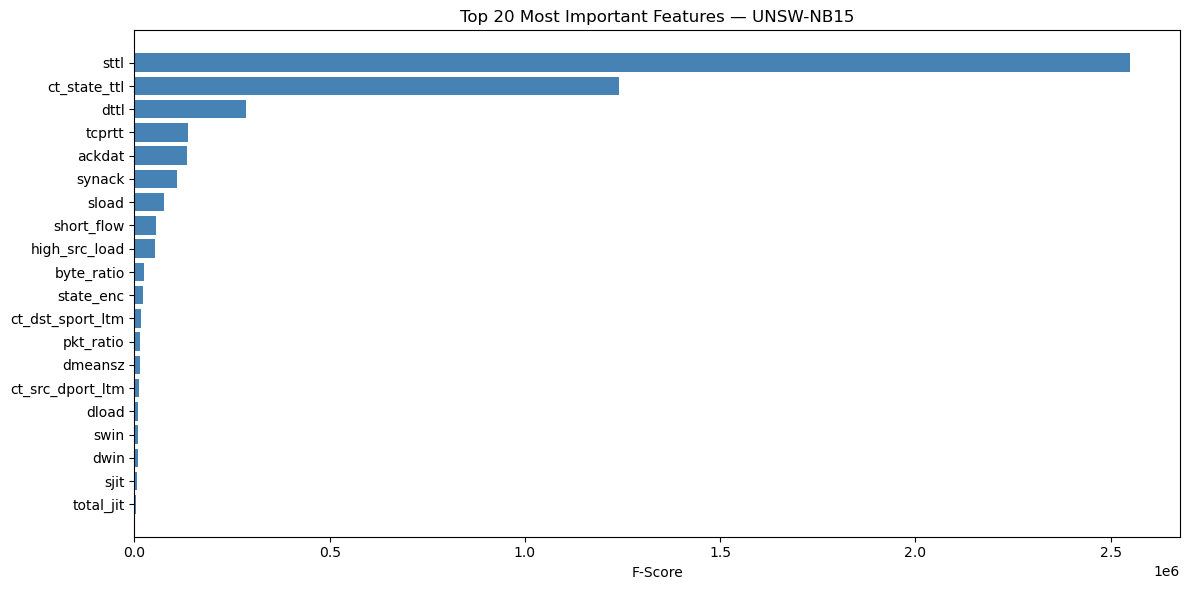


Top 20 features:
         feature        score
            sttl 2.549873e+06
    ct_state_ttl 1.240963e+06
            dttl 2.856954e+05
          tcprtt 1.379304e+05
          ackdat 1.355006e+05
          synack 1.077919e+05
           sload 7.657961e+04
      short_flow 5.470700e+04
   high_src_load 5.325661e+04
      byte_ratio 2.496938e+04
       state_enc 2.084194e+04
ct_dst_sport_ltm 1.688452e+04
       pkt_ratio 1.492599e+04
         dmeansz 1.318286e+04
ct_src_dport_ltm 1.117189e+04
           dload 1.025759e+04
            swin 8.868280e+03
            dwin 8.809945e+03
            sjit 6.263000e+03
       total_jit 3.966378e+03


In [8]:
X_all = df2.drop(columns=['binary_label'])
y_all = df2['binary_label']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y_all)

feat_scores = pd.DataFrame({
    'feature': X_all.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

# Plot top 20
top20 = feat_scores.head(20)
plt.figure(figsize=(12, 6))
plt.barh(top20['feature'][::-1], top20['score'][::-1], color='steelblue')
plt.xlabel('F-Score')
plt.title('Top 20 Most Important Features — UNSW-NB15')
plt.tight_layout()
plt.show()

print('\nTop 20 features:')
print(top20.to_string(index=False))

In [10]:
# Keep top 20 features
TOP_N = 20
top_features = feat_scores.head(TOP_N)['feature'].tolist()

X = df2[top_features]
y = df2['binary_label']

print(f'Features selected: {top_features}')
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

Features selected: ['sttl', 'ct_state_ttl', 'dttl', 'tcprtt', 'ackdat', 'synack', 'sload', 'short_flow', 'high_src_load', 'byte_ratio', 'state_enc', 'ct_dst_sport_ltm', 'pkt_ratio', 'dmeansz', 'ct_src_dport_ltm', 'dload', 'swin', 'dwin', 'sjit', 'total_jit']
X shape: (1087203, 20)  |  y shape: (1087203,)


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=top_features)

print(' Features scaled using StandardScaler')
X_scaled.describe().T.head(5)

 Features scaled using StandardScaler


,count,mean,std,min,25%,50%,75%,max
sttl,1087203.0,4.015418e-17,1.0,-1.104317,-0.146310,-0.146310,-0.146310,6.776058
ct_state_ttl,1087203.0,1.338473e-17,1.0,-0.152785,-0.152785,-0.152785,-0.152785,19.455878
dttl,1087203.0,4.684654e-17,1.0,-1.255637,-0.074079,-0.074079,-0.074079,9.093181
tcprtt,1087203.0,0.000000e+00,1.0,-0.110517,-0.110517,-0.080454,-0.077480,151.005027
ackdat,1087203.0,1.338473e-17,1.0,-0.091443,-0.091443,-0.079602,-0.077999,164.841582


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train attack rate: {y_train.mean():.2%}')
print(f'y_test  attack rate: {y_test.mean():.2%}')

X_train: (869762, 20)  |  X_test: (217441, 20)
y_train attack rate: 2.04%
y_test  attack rate: 2.04%


In [13]:
import joblib
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv',   index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv',   index=False)

joblib.dump(scaler,       'models/scaler.pkl')
joblib.dump(top_features, 'models/feature_names.pkl')

print('Saved:')
print('  data/processed/X_train.csv')
print('  data/processed/X_test.csv')
print('  data/processed/y_train.csv')
print('  data/processed/y_test.csv')
print('  models/scaler.pkl')
print('  models/feature_names.pkl')
print('\n Next step: Open 03_model_training.ipynb')

Saved:
  data/processed/X_train.csv
  data/processed/X_test.csv
  data/processed/y_train.csv
  data/processed/y_test.csv
  models/scaler.pkl
  models/feature_names.pkl

 Next step: Open 03_model_training.ipynb
